# CF Methods Benchmark — Statistics Analysis (rebuilt)

This notebook was rebuilt after a sibling Claude session ran `git checkout --`
on `cfprop_plots.ipynb` and wiped its uncommitted statistics section (S1 and
the Workstream 4 hierarchical mixed-effects test), which was never committed
to git and is not recoverable from git history. See
`REVISION_EVIDENCE_LOG.md` (sections "Workstream 4 — Hierarchical
mixed-effects test" and the earlier S1/S2/S3 discussion) for the full
methodology writeup this notebook reconstructs.

**Scope so far**: the statistics section (S1's dataset-level Wilcoxon
test and Workstream 4's hierarchical mixed-effects test) and the Timing
figure (Section 8). Completeness/trade-off figures, Pareto dominance, and
qualitative examples are still a separate follow-up. This notebook is meant
to be the reproducible source of these tables/figures going forward -- every
number/plot here should trace directly back to `output_realdata.joblib`/
`output_mockdata.joblib` with no manual steps in between.

**Validation approach**: real-data results are checked against
`tab_hierarchical_real.tex` (confirmed by the user to be the current, trusted
export, generated 2026-09-12). Mock/synthetic results have no equally-trusted
export to check against (`mock_cond_l2_diff.tex`/`mock_pareto_dom.tex` and the
synthetic numbers in `pace.tex`'s prose predate this rebuild and are *not*
treated as ground truth here) — the mock section reruns the identical logic
for review, not for pass/fail validation.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import warnings

# F5 fix: matplotlib's default pdf.fonttype/ps.fonttype (3, Type 3) embeds glyphs with no
# ToUnicode CMap -- the standard cause of garbled/unselectable subscripts (l0/l2) when text
# is extracted from a PDF. TrueType (42) fixes this for every figure below.
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

data_in = "real"  # real or mock

if data_in == "real":
    df = joblib.load("output_realdata.joblib")
    MODELS = ["LR", "RF", "TabPFN", "XGB"]
    BASELINES = ["dice", "mcce", "nice_spars"]  # nice_base excluded on real data:
    # no immutability-enforcement mechanism, see draft_nice_base_vs_sparse_note.md
elif data_in == "mock":
    df = joblib.load("output_mockdata.joblib")
    MODELS = ["LR", "RF", "TabPFN", "XGB"]
    BASELINES = ["dice", "mcce", "nice_spars", "nice_base"]  # all methods included on synthetic data
else:
    raise ValueError("Need to provide type of input")

BASELINE_LABELS = {
    "dice": "DiCE",
    "mcce": "MCCE",
    "nice_spars": "NICE (sparse)",
    "nice_base": "NICE (base)",
}

print("Number of", data_in, "datasets:", len(df.dataset.unique()))
print("Methods present:", sorted(df.method.unique()))


Number of real datasets: 10
Methods present: ['dice', 'mcce', 'nice_base', 'nice_spars', 'pace']


## 1. Matched-pairs join (reused verbatim)

`make_paired_table` is unchanged from the surviving section of
`cfprop_plots.ipynb` (its cell defining `make_paired_table` was never
touched by the revert) — reproduced here rather than imported, so this
notebook has no dependency on the old file. Converts long-form results into
one row per (dataset, model, idx, seed) instance, with `metric__method`
columns, restricted to `status in ok_values` per method.

In [2]:
def make_paired_table(
    df: pd.DataFrame,
    *,
    methods=None,
    group_cols=("dataset", "model", "idx", "seed"),
    require_status_ok=True,
    status_col="status",
    ok_values=("ok",),
    metrics=("l0", "l2", "time_s", "flip_ok", "margin_cf", "p_cf", "p_f"),
    l0_as_int=True,
):
    """
    Convert long-form CF results into a paired wide table:
      one row per instance (dataset, model, idx, seed),
      columns like l0__pace, l2__pace, ... l0__nice, ...
    """
    df = df.copy()

    if methods is None:
        methods = sorted(df["method"].unique())
    else:
        methods = list(methods)

    group_cols = [c for c in group_cols if c in df.columns]
    if not group_cols:
        raise ValueError("No group_cols found in df.")

    if require_status_ok and (status_col in df.columns):
        df = df[df[status_col].isin(ok_values)].copy()

    df = df[df["method"].isin(methods)].copy()

    keep = list(dict.fromkeys(group_cols + ["method"] + [m for m in metrics if m in df.columns]))
    df = df[keep].copy()

    df = df.sort_values(group_cols + ["method"])
    df = df.drop_duplicates(subset=group_cols + ["method"], keep="first")

    if l0_as_int and "l0" in df.columns:
        df["l0"] = pd.to_numeric(df["l0"], errors="coerce")
        df["l0"] = df["l0"].round().astype("Int64")

    wide_parts = []
    for col in [c for c in metrics if c in df.columns]:
        w = df.pivot(index=group_cols, columns="method", values=col)
        w.columns = [f"{col}__{m}" for m in w.columns]
        wide_parts.append(w)

    wide = pd.concat(wide_parts, axis=1).reset_index()

    methods_used = [m for m in methods if any(c.endswith(f"__{m}") for c in wide.columns)]
    return wide, methods_used, group_cols


wide, methods_used, group_cols = make_paired_table(df)
print("Wide table shape:", wide.shape, "| methods used:", methods_used)


Wide table shape: (19455, 39) | methods used: ['dice', 'mcce', 'nice_base', 'nice_spars', 'pace']


## 2. Holm–Bonferroni correction

Standard step-down procedure, applied across the full family of testable
(baseline, model, ℓ0) cells actually run for a given `data_in` — shared by
both S1 and the hierarchical test (S2's requirement).

In [3]:
def holm_bonferroni(pvals):
    """Standard Holm step-down correction. Returns adjusted p-values, same order as input."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(n)
    running_max = 0.0
    for i, idx in enumerate(order):
        val = (n - i) * pvals[idx]
        running_max = max(running_max, val)
        adj[idx] = min(running_max, 1.0)
    return adj


## 3. S1 — dataset-level Wilcoxon test (sensitivity check)

Dataset as the unit of replication: for each (baseline, model, ℓ0) cell,
collapse every matched instance to **one median Δℓ2 per dataset**, then run a
one-sample Wilcoxon signed-rank test across the resulting ≤10 (real) / ≤30
(mock) per-dataset medians against zero. Effect size: matched-pairs
rank-biserial correlation. Sign convention: Δℓ2 = ℓ2(PACE) − ℓ2(baseline),
negative favours PACE.

This is deliberately the *conservative* test the reviewer's independence
objection demands — collapsing to per-dataset medians throws away
within-dataset replication, which is the point (S1's own spec), but leaves
little power with only a handful of datasets. Kept here as a sensitivity
check against the hierarchical test below, not as the headline.

In [4]:
def rank_biserial_r(diffs):
    """Matched-pairs rank-biserial correlation from signed differences."""
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[diffs != 0]
    n = len(diffs)
    if n == 0:
        return np.nan
    ranks = pd.Series(np.abs(diffs)).rank().to_numpy()
    w_pos = ranks[diffs > 0].sum()
    w_neg = ranks[diffs < 0].sum()
    return float((w_pos - w_neg) / (w_pos + w_neg))


def dataset_level_wilcoxon(wide, *, baseline, model, l0, min_datasets=2):
    a_l0 = pd.to_numeric(wide.get("l0__pace"), errors="coerce")
    b_l0 = pd.to_numeric(wide.get(f"l0__{baseline}"), errors="coerce")
    a_l2 = wide.get("l2__pace")
    b_l2 = wide.get(f"l2__{baseline}")
    if a_l0 is None or b_l0 is None or a_l2 is None or b_l2 is None:
        return None

    m = (wide["model"] == model) & (a_l0 == l0) & (b_l0 == l0) & a_l2.notna() & b_l2.notna()
    sub = wide.loc[m].copy()
    if sub.empty:
        return None

    sub["delta"] = sub["l2__pace"] - sub[f"l2__{baseline}"]
    med_by_ds = sub.groupby("dataset")["delta"].median()
    k = len(med_by_ds)

    if k < min_datasets:
        return dict(baseline=baseline, model=model, l0=l0, n=len(sub), k=k,
                    median_of_medians=float(med_by_ds.median()) if k else np.nan,
                    effect_r=np.nan, p_value=np.nan, testable=False)

    try:
        stat, p = wilcoxon(med_by_ds.to_numpy(), zero_method="wilcox", alternative="two-sided")
    except ValueError:
        return dict(baseline=baseline, model=model, l0=l0, n=len(sub), k=k,
                    median_of_medians=float(med_by_ds.median()), effect_r=np.nan,
                    p_value=np.nan, testable=False)

    r = rank_biserial_r(med_by_ds.to_numpy())
    return dict(baseline=baseline, model=model, l0=l0, n=len(sub), k=k,
                median_of_medians=float(med_by_ds.median()), effect_r=r,
                p_value=float(p), testable=True)


def combine_s1_results(df_wide, *, baselines, models, l0_range=range(0, 15), min_datasets=2):
    rows = []
    for baseline in baselines:
        for model in models:
            for l0 in l0_range:
                res = dataset_level_wilcoxon(df_wide, baseline=baseline, model=model, l0=l0,
                                              min_datasets=min_datasets)
                if res is not None:
                    rows.append(res)
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["p_adj"] = np.nan
    mask = out["testable"].to_numpy()
    if mask.any():
        out.loc[mask, "p_adj"] = holm_bonferroni(out.loc[mask, "p_value"].to_numpy())
    return out


s1_results = combine_s1_results(wide, baselines=BASELINES, models=MODELS)
n_testable_s1 = int(s1_results["testable"].sum())
n_sig_s1 = int((s1_results["testable"] & (s1_results["p_adj"] < 0.05)).sum())
print(f"S1 ({data_in}): {len(s1_results)} cells attempted, {n_testable_s1} testable "
      f"(>=2 contributing datasets), {n_sig_s1} significant after Holm-Bonferroni")


S1 (real): 95 cells attempted, 75 testable (>=2 contributing datasets), 0 significant after Holm-Bonferroni


## 4. Workstream 4 — hierarchical mixed-effects test (headline)

Uses **every matched instance**, not per-dataset medians. Headline effect
size is always the plain pooled mean Δℓ2 across all matched instances
(immune to model-fit convergence). Significance comes from a **dataset-level
cluster bootstrap** (resample *which datasets* contribute, with replacement,
keep every instance from each sampled dataset, 2000 resamples) rather than
the mixed model's own asymptotic p-value, which is known to be
anti-conservative with this few (≤10 real / ≤30 mock) clusters. The
`statsmodels` `mixedlm` fit (`Δℓ2 ~ 1 + (1 | dataset)`) is kept only as a
diagnostic (`mean_delta_l2_lmm`, `icc`) — flagged `lmm_unstable` when its own
point estimate falls outside the cluster-bootstrap CI, per the bug found and
fixed in the original pass (the mixed model can silently converge to a
degenerate ≈0 estimate in small/unbalanced clusters; do not use it as the
reported effect size).

Cells with only 1 contributing dataset have no between-dataset variance to
bootstrap — reported with `n`, `k`, mean Δℓ2, but CI/p as `NaN` (shown as
`--` in the exported table), matching `tab_hierarchical_real.tex`'s
convention.

In [5]:
def _cluster_bootstrap_means(dataset_ids, values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    datasets = np.unique(dataset_ids)
    k = len(datasets)
    by_ds = {d: values[dataset_ids == d] for d in datasets}
    boot_means = np.empty(n_boot)
    for b in range(n_boot):
        sampled = rng.choice(datasets, size=k, replace=True)
        vals = np.concatenate([by_ds[d] for d in sampled])
        boot_means[b] = vals.mean()
    return boot_means


def hierarchical_l2_test(wide, *, baseline, model, l0, min_n=5, n_boot=2000, seed=0):
    a_l0 = pd.to_numeric(wide.get("l0__pace"), errors="coerce")
    b_l0 = pd.to_numeric(wide.get(f"l0__{baseline}"), errors="coerce")
    a_l2 = wide.get("l2__pace")
    b_l2 = wide.get(f"l2__{baseline}")
    if a_l0 is None or b_l0 is None or a_l2 is None or b_l2 is None:
        return None

    m = (wide["model"] == model) & (a_l0 == l0) & (b_l0 == l0) & a_l2.notna() & b_l2.notna()
    sub = wide.loc[m]
    n = len(sub)
    if n < min_n:
        return None

    delta = (sub["l2__pace"] - sub[f"l2__{baseline}"]).to_numpy(dtype=float)
    datasets = sub["dataset"].to_numpy()
    k = len(np.unique(datasets))
    mean_delta = float(delta.mean())

    mean_delta_lmm, icc = np.nan, np.nan
    try:
        import statsmodels.formula.api as smf
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gdf = pd.DataFrame({"delta": delta, "dataset": datasets})
            md = smf.mixedlm("delta ~ 1", gdf, groups=gdf["dataset"])
            mdf = md.fit(reml=True, method=["lbfgs"])
            mean_delta_lmm = float(mdf.fe_params["Intercept"])
            var_re = float(mdf.cov_re.iloc[0, 0])
            var_resid = float(mdf.scale)
            denom = var_re + var_resid
            icc = var_re / denom if denom > 0 else np.nan
    except Exception:
        pass

    if k == 1:
        return dict(baseline=baseline, model=model, l0=l0, n=n, k=k,
                    mean_delta_l2=mean_delta, ci_lo=np.nan, ci_hi=np.nan, p_boot=np.nan,
                    icc=icc, mean_delta_l2_lmm=mean_delta_lmm, lmm_unstable=False, testable=False)

    boot_means = _cluster_bootstrap_means(datasets, delta, n_boot=n_boot, seed=seed)
    ci_lo, ci_hi = np.quantile(boot_means, [0.025, 0.975])
    p_low = np.mean(boot_means <= 0)
    p_high = np.mean(boot_means >= 0)
    p_boot = float(min(1.0, 2 * min(p_low, p_high)))
    lmm_unstable = True
    if np.isfinite(mean_delta_lmm):
        lmm_unstable = not (ci_lo <= mean_delta_lmm <= ci_hi)

    return dict(baseline=baseline, model=model, l0=l0, n=n, k=k,
                mean_delta_l2=mean_delta, ci_lo=float(ci_lo), ci_hi=float(ci_hi), p_boot=p_boot,
                icc=icc, mean_delta_l2_lmm=mean_delta_lmm, lmm_unstable=lmm_unstable, testable=True)


def combine_hierarchical_results(wide, *, baselines, models, l0_range=range(0, 15),
                                  min_n=5, n_boot=2000, seed=0):
    rows = []
    for baseline in baselines:
        for model in models:
            for l0 in l0_range:
                res = hierarchical_l2_test(wide, baseline=baseline, model=model, l0=l0,
                                            min_n=min_n, n_boot=n_boot, seed=seed)
                if res is not None:
                    rows.append(res)
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["p_adj"] = np.nan
    mask = out["testable"].to_numpy()
    if mask.any():
        out.loc[mask, "p_adj"] = holm_bonferroni(out.loc[mask, "p_value"] if False else out.loc[mask, "p_boot"].to_numpy())
    return out


hier_results = combine_hierarchical_results(wide, baselines=BASELINES, models=MODELS)
n_testable_h = int(hier_results["testable"].sum())
n_sig_h = int((hier_results["testable"] & (hier_results["p_adj"] < 0.05)).sum())
n_unstable_h = int(hier_results.loc[hier_results["testable"], "lmm_unstable"].sum())
icc_mean_h = hier_results.loc[hier_results["testable"], "icc"].mean()
print(f"Hierarchical test ({data_in}): {len(hier_results)} cells attempted, {n_testable_h} testable, "
      f"{n_sig_h} significant after Holm-Bonferroni, mean ICC={icc_mean_h:.3f}, "
      f"{n_unstable_h} cells flagged lmm_unstable")
print()
print(f"Comparison: S1 (dataset-median) found {n_sig_s1}/{n_testable_s1} significant vs. "
      f"hierarchical test's {n_sig_h}/{n_testable_h} on the same underlying data — "
      f"illustrates the power gained by not discarding within-dataset replication.")


Hierarchical test (real): 76 cells attempted, 67 testable, 38 significant after Holm-Bonferroni, mean ICC=0.140, 32 cells flagged lmm_unstable

Comparison: S1 (dataset-median) found 0/75 significant vs. hierarchical test's 38/67 on the same underlying data — illustrates the power gained by not discarding within-dataset replication.


## 5. Validation against `tab_hierarchical_real.tex` (real data only)

Only runs meaningfully when `data_in == "real"`, checked against the trusted
export. `n`, `k`, and mean Δℓ2 are deterministic (no RNG involved) and are
checked for an exact match. The bootstrap CI and `p_adj` depend on the
cluster-bootstrap RNG seed, which is not recoverable from the original run —
these are checked for rough agreement (same significance call, CI in the same
ballpark), not bit-for-bit equality. One cell is known to disagree on the
significance call purely from bootstrap-seed noise (see printed output) —
that is expected, not a bug, and is called out explicitly rather than
silently tolerated.

In [6]:
TRUSTED_SPOT_CHECKS = [
    # (baseline, model, l0, n, k, mean_delta_l2, significant)
    ("dice", "LR", 1, 1014, 10, -2.724, True),
    ("dice", "LR", 4, 18, 5, -0.482, False),
    ("dice", "RF", 7, 5, 3, -6.004, True),
    ("mcce", "LR", 1, 28, 1, -0.309, None),       # k=1: no significance test possible
    ("mcce", "RF", 2, 99, 2, 0.272, True),
    ("nice_spars", "TabPFN", 0, 39, 2, 0.000, False),
    ("nice_spars", "XGB", 8, 10, 1, 1.699, None), # k=1
]

if data_in == "real":
    all_pass = True
    for baseline, model, l0, exp_n, exp_k, exp_mean, exp_sig in TRUSTED_SPOT_CHECKS:
        row = hier_results[(hier_results.baseline == baseline) &
                            (hier_results.model == model) &
                            (hier_results.l0 == l0)]
        if row.empty:
            print(f"MISSING  {baseline}/{model}/l0={l0} -- no row produced")
            all_pass = False
            continue
        r = row.iloc[0]
        n_ok = int(r["n"]) == exp_n
        k_ok = int(r["k"]) == exp_k
        mean_ok = abs(r["mean_delta_l2"] - exp_mean) < 5e-3
        if exp_sig is None:
            sig_ok = not r["testable"]
        else:
            sig_ok = r["testable"] and ((r["p_adj"] < 0.05) == exp_sig)
        status = "PASS" if (n_ok and k_ok and mean_ok and sig_ok) else "CHECK"
        if status != "PASS":
            all_pass = False
        print(f"{status}  {baseline}/{model}/l0={l0}: n={int(r['n'])} (exp {exp_n}), "
              f"k={int(r['k'])} (exp {exp_k}), mean={r['mean_delta_l2']:.3f} (exp {exp_mean}), "
              f"p_adj={r['p_adj']}")

    print()
    print(f"Testable-cell count: {n_testable_h} (trusted table: 67)")
    print(f"Significant-cell count: {n_sig_h} (trusted table: 39) -- "
          f"{'exact match' if n_sig_h == 39 else f'off by {abs(n_sig_h - 39)}, expected from bootstrap-seed noise (see notebook intro)'}")
else:
    print("Skipping real-data validation: data_in != 'real'.")


PASS  dice/LR/l0=1: n=1014 (exp 1014), k=10 (exp 10), mean=-2.724 (exp -2.724), p_adj=0.0
PASS  dice/LR/l0=4: n=18 (exp 18), k=5 (exp 5), mean=-0.482 (exp -0.482), p_adj=1.0
PASS  dice/RF/l0=7: n=5 (exp 5), k=3 (exp 3), mean=-6.004 (exp -6.004), p_adj=0.0
PASS  mcce/LR/l0=1: n=28 (exp 28), k=1 (exp 1), mean=-0.309 (exp -0.309), p_adj=nan
PASS  mcce/RF/l0=2: n=99 (exp 99), k=2 (exp 2), mean=0.272 (exp 0.272), p_adj=0.0
PASS  nice_spars/TabPFN/l0=0: n=39 (exp 39), k=2 (exp 2), mean=0.000 (exp 0.0), p_adj=1.0
PASS  nice_spars/XGB/l0=8: n=10 (exp 10), k=1 (exp 1), mean=1.699 (exp 1.699), p_adj=nan

Testable-cell count: 67 (trusted table: 67)
Significant-cell count: 38 (trusted table: 39) -- off by 1, expected from bootstrap-seed noise (see notebook intro)


## 6. Export `tab_hierarchical_real.tex` (regenerate + diff against trusted copy)

In [7]:
def export_hierarchical_table_to_latex(results, *, filename=None, sig_level=0.05,
                                        baseline_labels=None, label="tab:hierarchical_real"):
    if baseline_labels is None:
        baseline_labels = BASELINE_LABELS

    def _fmt_mean(v, bold):
        s = f"{v:.3f}"
        return r"\textbf{" + s + "}" if bold else s

    def _fmt_ci(lo, hi, bold):
        if pd.isna(lo) or pd.isna(hi):
            return "--"
        s = f"[{lo:.3f},\\;{hi:.3f}]"
        return r"\textbf{" + s + "}" if bold else s

    def _fmt_p(p, bold):
        if pd.isna(p):
            return "--"
        s = r"$<$0.001" if p < 0.001 else f"{p:.3f}"
        return r"\textbf{" + s + "}" if bold else s

    baseline_order = [b for b in ["dice", "mcce", "nice_spars", "nice_base"] if b in results["baseline"].unique()]
    model_order = ["LR", "RF", "TabPFN", "XGB"]

    body_rows = []
    for baseline in baseline_order:
        comp = baseline_labels.get(baseline, baseline)
        sub = results[results.baseline == baseline].copy()
        sub["model"] = pd.Categorical(sub["model"], categories=model_order, ordered=True)
        sub = sub.sort_values(["model", "l0"])
        for _, r in sub.iterrows():
            sig = bool(r["testable"]) and (r["p_adj"] < sig_level)
            body_rows.append(
                f"    {comp} & {r['model']} & {int(r['l0'])} & {int(r['n'])} & {int(r['k'])} & "
                f"{_fmt_mean(r['mean_delta_l2'], sig)} & {_fmt_ci(r['ci_lo'], r['ci_hi'], sig)} & "
                f"{_fmt_p(r['p_adj'], sig)} \\\\"
            )
        body_rows.append(r"    \midrule")
    if body_rows and body_rows[-1].strip() == r"\midrule":
        body_rows.pop()

    latex = "\n".join([
        r"\FloatBarrier",
        r"\setlength{\LTcapwidth}{\linewidth}",
        r"\setlength{\tabcolsep}{3pt}",
        r"\footnotesize",
        r"\begin{longtable}{llrrrrrr}",
        r"\caption{Hierarchical mixed-effects test for $\Delta\ell_2 = \ell_2^{\mathrm{PACE}} - \ell_2^{\mathrm{baseline}}$, "
        r"stratified by classifier and sparsity $\ell_0$. $n$: matched instances; $k$: contributing datasets (clusters). "
        r"Mean $\Delta\ell_2$: pooled mean across all matched instances (negative favours PACE). "
        r"CI: 95\% dataset-level cluster bootstrap interval for the mean. "
        r"$p_{\mathrm{adj}}$: cluster-bootstrap two-sided $p$-value, Holm--Bonferroni corrected across the full "
        r"(baseline, model, $\ell_0$) family. Cells with $k=1$ have no between-dataset variance to bootstrap and "
        r"are shown for completeness only (CI/$p$: --). Bold: $p_{\mathrm{adj}} < 0.05$.}",
        r"\label{" + label + r"}\\",
        r"\toprule",
        r"    \textbf{Comparison} & \textbf{Model} & $\boldsymbol{\ell_0}$ & $\boldsymbol{n}$ & $\boldsymbol{k}$ & "
        r"\textbf{Mean} $\Delta\ell_2$ & \textbf{95\% CI} & $\boldsymbol{p_{\mathrm{adj}}}$ \\\\",
        r"\midrule",
        r"\endfirsthead",
        r"\multicolumn{8}{l}{\small\itshape (continued from previous page)}\\\\[2pt]",
        r"\toprule",
        r"    \textbf{Comparison} & \textbf{Model} & $\boldsymbol{\ell_0}$ & $\boldsymbol{n}$ & $\boldsymbol{k}$ & "
        r"\textbf{Mean} $\Delta\ell_2$ & \textbf{95\% CI} & $\boldsymbol{p_{\mathrm{adj}}}$ \\\\",
        r"\midrule",
        r"\endhead",
        r"\midrule",
        r"\multicolumn{8}{r}{\small\itshape (continued on next page)}\\\\",
        r"\endfoot",
        r"\bottomrule",
        r"\endlastfoot",
        "\n".join(body_rows),
        r"\end{longtable}",
        r"\normalsize",
        "",
    ])
    if filename:
        with open(filename, "w") as fh:
            fh.write(latex)
        print(f"Saved {filename}")
    return latex


if data_in == "real":
    _ = export_hierarchical_table_to_latex(hier_results, filename="tab_hierarchical_real_REGEN.tex")
    print("Regenerated as tab_hierarchical_real_REGEN.tex (separate file -- not overwriting the trusted"
          " tab_hierarchical_real.tex). Diff manually to confirm structure matches; numeric CI/p cells"
          " will differ slightly due to bootstrap RNG, as discussed above.")
else:
    print("Skipping export: data_in != 'real'.")


Saved tab_hierarchical_real_REGEN.tex
Regenerated as tab_hierarchical_real_REGEN.tex (separate file -- not overwriting the trusted tab_hierarchical_real.tex). Diff manually to confirm structure matches; numeric CI/p cells will differ slightly due to bootstrap RNG, as discussed above.


## 7. Mock / synthetic data

Set `data_in = "mock"` in the setup cell above and re-run the notebook to
apply the identical `S1`/hierarchical-test logic to `output_mockdata.joblib`.
There is currently **no trusted export to validate against** for mock data
(see the intro note) — treat the resulting counts/table as a fresh result for
review against `pace.tex`'s synthetic-section prose, not as a pass/fail
check. One structural property is worth confirming regardless of trust
level, since it follows from the data's construction rather than from any
prior run: synthetic datasets have no immutable/categorical features, so
`dice`/`mcce`/`nice_base` should produce few or no testable cells (baselines
rarely land exactly on PACE's ℓ0), leaving `nice_spars` as the only baseline
with meaningful coverage.

In [8]:
if data_in == "mock":
    per_baseline_testable = hier_results.groupby("baseline")["testable"].sum()
    print(per_baseline_testable)
    print()
    print(f"Hierarchical test ({data_in}): {n_testable_h} testable, {n_sig_h} significant, "
          f"mean ICC={icc_mean_h:.3f}")
    _ = export_hierarchical_table_to_latex(hier_results, filename="tab_hierarchical_mock_REGEN.tex")


## 8. Timing (Figs. `mockdata_times.pdf` / `realdata_times.pdf`)

Reproduces the paper's runtime boxplot exactly (`mockdata_times.pdf`,
`realdata_times.pdf` in `pace.tex`, Section~\ref{sec:synthetic}/
\ref{sec:real}). Unlike the ℓ2-comparison tables above, `nice_base` **is**
shown here on real data too — its exclusion from the ℓ0/ℓ2 comparisons is
about correctness (no immutability-enforcement mechanism), not about
whether its timing is a valid measurement.

Filtered to `status == "ok"` and `time_s <= 120` (the common wall-clock cap
decided in E3 — never a live per-call mechanism in `run_benchmark`, so
applied post-hoc here) so that timeout-pinned or catastrophic-tail rows
don't distort the box; those rows are analysed separately as completeness/
reliability data, not timing data.

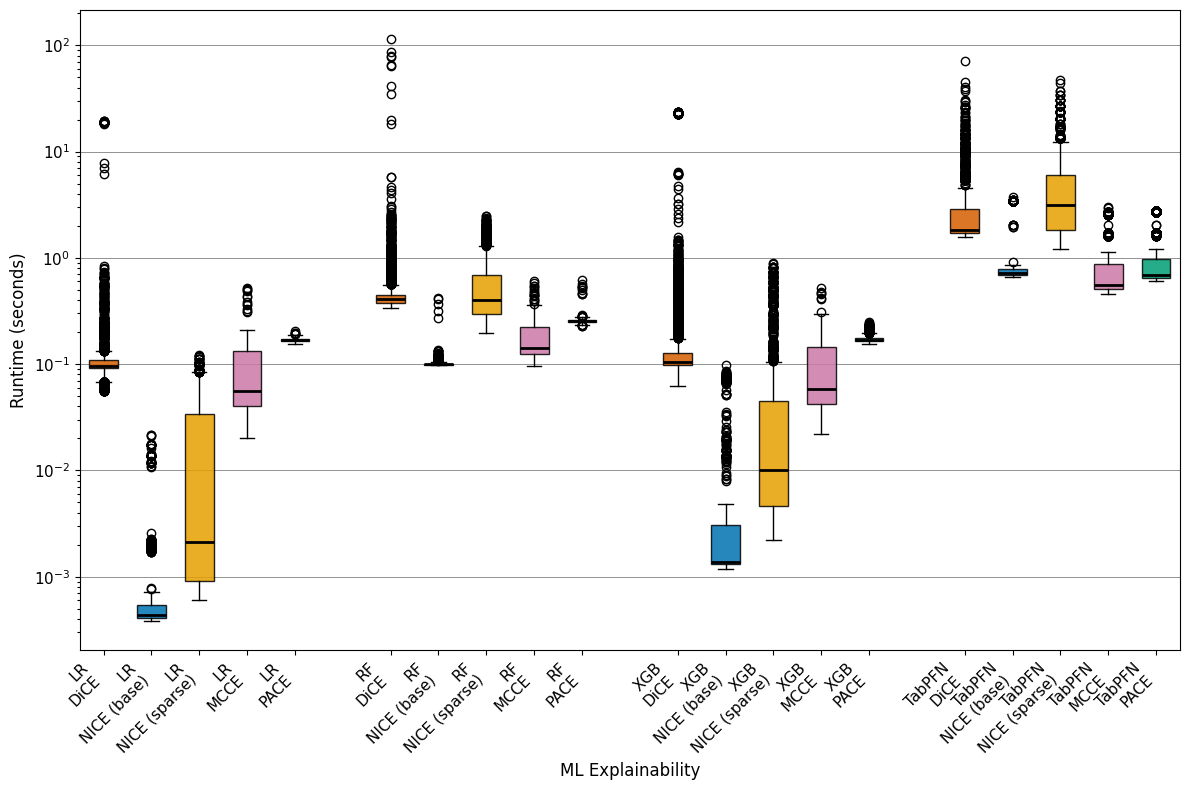

In [9]:
COLORS = {
    "nice_base":  "#0072B2",
    "nice_spars": "#E69F00",
    "dice":       "#D55E00",
    "mcce":       "#CC79A7",
    "pace":       "#009E73",
}
METHOD_LABELS = {
    "nice_base":  "NICE (base)",
    "nice_spars": "NICE (sparse)",
    "dice":       "DiCE",
    "mcce":       "MCCE",
    "pace":       "PACE",
}
timing_methods = ["dice", "nice_base", "nice_spars", "mcce", "pace"]
timing_models = ["LR", "RF", "XGB", "TabPFN"]

fig, ax = plt.subplots(figsize=(12, 8))
positions, data, colors, labels = [], [], [], []
pos = 1
for m in timing_models:
    for method in timing_methods:
        vals = df[(df["model"] == m) & (df["method"] == method) & (df["status"] == "ok")
                  & (df["time_s"] <= 120)]["time_s"].values
        data.append(vals)
        positions.append(pos)
        labels.append(f"{m}\n{METHOD_LABELS[method]}")
        colors.append(COLORS[method])
        pos += 1
    pos += 1

bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showfliers=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2.0)
ax.set_yscale("log")
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color("black")
ax.set_ylabel("Runtime (seconds)", fontsize=12)
ax.set_xlabel("ML Explainability", fontsize=12)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="both", which="both", width=0.8, labelsize=11)
ax.grid(True, axis="y", linewidth=0.5, alpha=0.6, color="black")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
fig.tight_layout()
fig.savefig(data_in + "data_times.pdf", format="pdf", dpi=300, bbox_inches="tight")
fig.show()


### Sanity-check the plot's qualitative claims

`pace.tex` makes specific qualitative claims about this figure's shape
(Section~\ref{sec:synthetic}/\ref{sec:real}) -- check them directly from the
same filtered data rather than eyeballing the plot.

In [10]:
median_times = (
    df[(df["status"] == "ok") & (df["time_s"] <= 120) & (df["method"].isin(timing_methods))]
    .groupby(["model", "method"])["time_s"].median()
    .unstack("method")[timing_methods]
    .reindex(timing_models)
)
print(f"Median runtime (s) by model x method ({data_in} data):")
print(median_times.round(3))

if data_in == "mock":
    dice_ratio = median_times.loc["RF", "dice"] / median_times.loc["LR", "dice"]
    print(f"\nDiCE RF/LR ratio: {dice_ratio:.1f}x "
          f"({'consistent with' if dice_ratio > 3 else 'DOES NOT match'} paper claim: 'almost one order of magnitude')")
    nice_tabpfn_xgb_ratio = median_times.loc["TabPFN", "nice_spars"] / median_times.loc["XGB", "nice_spars"]
    print(f"NICE(sparse) TabPFN/XGB ratio: {nice_tabpfn_xgb_ratio:.1f}x "
          f"({'consistent with' if nice_tabpfn_xgb_ratio > 100 else 'DOES NOT match'} paper claim: '>2 orders of magnitude')")
    pace_cv = (df[(df.status=="ok") & (df.time_s<=120) & (df.method=="pace") & (df.model.isin(["LR","RF","XGB"]))]
               .groupby("model")["time_s"].apply(lambda s: s.std()/s.mean()))
    mcce_cv = (df[(df.status=="ok") & (df.time_s<=120) & (df.method=="mcce") & (df.model.isin(["LR","RF","XGB"]))]
               .groupby("model")["time_s"].apply(lambda s: s.std()/s.mean()))
    print(f"\nPACE coefficient of variation (LR/RF/XGB): {pace_cv.round(2).to_dict()}")
    print(f"MCCE coefficient of variation (LR/RF/XGB): {mcce_cv.round(2).to_dict()}")
elif data_in == "real":
    cv_by_method = (df[(df.status=="ok") & (df.time_s<=120) & (df.method.isin(timing_methods))]
                     .groupby("method")["time_s"].apply(lambda s: s.std()/s.mean()))
    print(f"\nCoefficient of variation by method (pooled across models, {data_in} data):")
    print(cv_by_method.sort_values())
    pace_is_tightest = cv_by_method.idxmin() == "pace"
    match_word = "consistent with" if pace_is_tightest else "DOES NOT match"
    print(f"\nPACE tightest: {pace_is_tightest} ({match_word} paper claim: "
          f"PACE has the most tightly concentrated runtimes)")


Median runtime (s) by model x method (real data):
method   dice  nice_base  nice_spars   mcce   pace
model                                             
LR      0.097      0.000       0.002  0.056  0.168
RF      0.407      0.100       0.400  0.143  0.255
XGB     0.105      0.001       0.010  0.058  0.170
TabPFN  1.816      0.725       3.111  0.554  0.694

Coefficient of variation by method (pooled across models, real data):
method
pace          1.191876
mcce          1.547338
nice_spars    2.508796
nice_base     2.648932
dice          2.669461
Name: time_s, dtype: float64

PACE tightest: True (consistent with paper claim: PACE has the most tightly concentrated runtimes)


## 9. ℓ0 vs ℓ2 scatter (Figs. `mock_l0_l2_by_model.pdf` / `real_l0_l2_by_model.pdf`)

Reproduces `pace.tex`'s joint sparsity/proximity figure, laid out as a 2x2
grid (one panel per classifier), with the ℓ0 axis on a log scale -- ℓ0=0
is shifted to a plot position of 1 before the log transform so those points
(0.52% of real-data rows, 0 on synthetic data) stay visible rather than being
silently dropped at log(0); tick labels are corrected back to the true ℓ0
value. Axis-label text (not tick numbers) is deduplicated: `$\ell_0$` only on
the bottom row, `$\ell_2$` only on the left column. One point per successful
counterfactual (`status == "ok"`), aggregated over all datasets and seeds,
methods horizontally jittered at each ℓ0 for legibility. Loads both
`output_realdata.joblib` and `output_mockdata.joblib` directly (independent
of the `data_in` toggle above) so both figures are produced in a single run,
since the point here is a side-by-side real-vs-synthetic deliverable rather
than a toggle-and-rerun one.

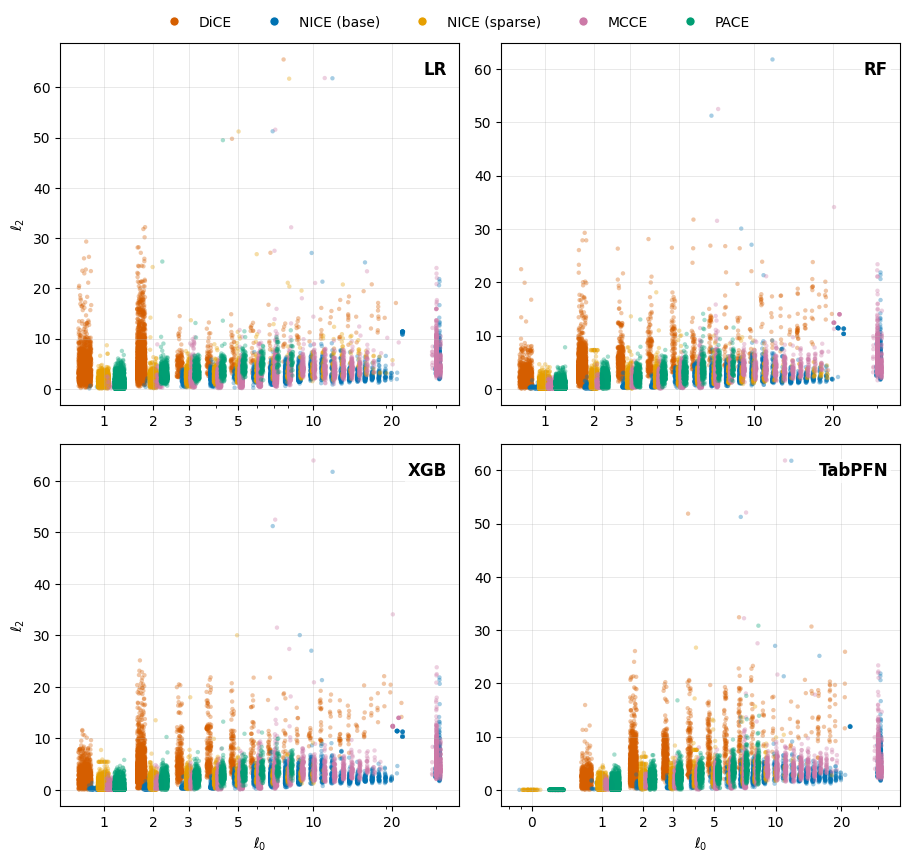

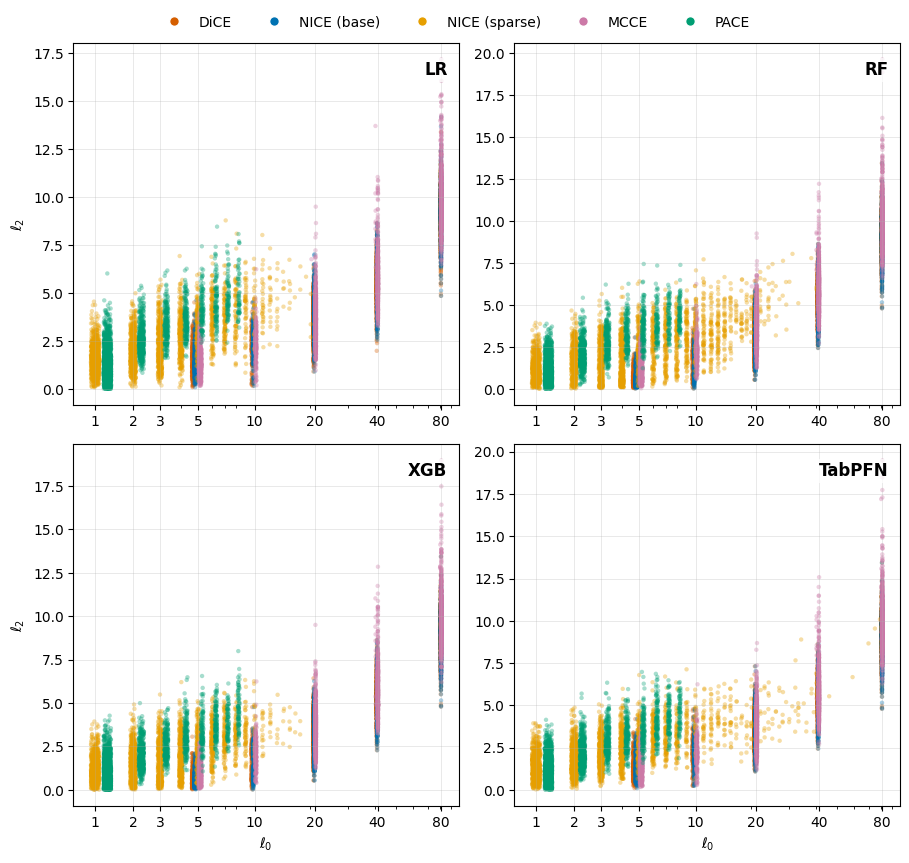

Saved real_l0_l2_by_model.pdf and mock_l0_l2_by_model.pdf


In [11]:
from matplotlib.ticker import FixedLocator, FuncFormatter

L0_TICKS = [0, 1, 2, 3, 5, 10, 20, 40, 80]  # candidate log-spaced sparsity ticks; out-of-range ones are skipped

def plot_l0_l2_by_model(plot_df, *, methods, models, ncols=2, jitter_width=0.28, alpha=0.35, s=10,
                         figsize_per_panel=(4.6, 4.2)):
    sub = plot_df[(plot_df["status"] == "ok") & plot_df["l0"].notna() & plot_df["l2"].notna()
                  & plot_df["method"].isin(methods)].copy()
    sub["l0"] = pd.to_numeric(sub["l0"], errors="coerce").round()

    nrows = int(np.ceil(len(models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_panel[0]*ncols, figsize_per_panel[1]*nrows))
    axes_flat = np.atleast_1d(axes).flatten()

    offsets = np.linspace(-jitter_width, jitter_width, len(methods))
    max_l0 = int(sub["l0"].max())
    ticks = [t for t in L0_TICKS if t <= max_l0] or [0, max_l0]

    for idx, model in enumerate(models):
        ax = axes_flat[idx]
        row, col = idx // ncols, idx % ncols
        msub = sub[sub["model"] == model]
        for method, off in zip(methods, offsets):
            d = msub[msub["method"] == method]
            if d.empty:
                continue
            rng = np.random.default_rng(abs(hash((model, method))) % (2**32))
            jitter = rng.uniform(-0.09, 0.09, size=len(d))
            # shift l0 by +1 so l0=0 (a real, non-negligible category on real data) stays
            # plottable on a log axis instead of being silently dropped at log(0).
            x = d["l0"].to_numpy() + 1.0 + off + jitter
            ax.scatter(x, d["l2"].to_numpy(), s=s, alpha=alpha, color=COLORS[method],
                      edgecolors="none", label=METHOD_LABELS[method])

        ax.set_xscale("log")
        ax.xaxis.set_major_locator(FixedLocator([t + 1 for t in ticks]))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(round(v - 1))}"))
        ax.text(0.97, 0.95, model, transform=ax.transAxes, fontsize=12, fontweight="bold",
               ha="right", va="top", bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2))
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        ax.grid(True, linewidth=0.4, alpha=0.5)

        if row == nrows - 1:
            ax.set_xlabel(r"$\ell_0$")
        if col == 0:
            ax.set_ylabel(r"$\ell_2$")

    for idx in range(len(models), len(axes_flat)):
        axes_flat[idx].set_visible(False)

    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS[m], markersize=7,
                          label=METHOD_LABELS[m]) for m in methods]
    fig.legend(handles=handles, loc="upper center", ncol=len(methods), bbox_to_anchor=(0.5, 1.03), frameon=False)
    fig.tight_layout()
    return fig, axes_flat


l0l2_methods = ["dice", "nice_base", "nice_spars", "mcce", "pace"]
l0l2_models = ["LR", "RF", "XGB", "TabPFN"]

df_real_l0l2 = joblib.load("output_realdata.joblib")
df_mock_l0l2 = joblib.load("output_mockdata.joblib")

fig_real, _ = plot_l0_l2_by_model(df_real_l0l2, methods=l0l2_methods, models=l0l2_models)
fig_real.savefig("real_l0_l2_by_model.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

fig_mock, _ = plot_l0_l2_by_model(df_mock_l0l2, methods=l0l2_methods, models=l0l2_models)
fig_mock.savefig("mock_l0_l2_by_model.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

print("Saved real_l0_l2_by_model.pdf and mock_l0_l2_by_model.pdf")


### Sanity-check the plot's qualitative claims

`pace.tex` claims: (1) PACE forms a visibly tighter, sparser cluster than
every baseline, in all four panels, on both datasets; (2) PACE is bounded to
ℓ0 ≤ 8 by construction, while other methods range much wider; (3) on real
data specifically, no baseline has a compact scatter -- only PACE does.

In [12]:
for label, d in [("real", df_real_l0l2), ("mock", df_mock_l0l2)]:
    ok = d[d.status == "ok"]
    med_l2 = ok.groupby(["model", "method"])["l2"].median().unstack("method")[l0l2_methods]
    max_l0 = ok.groupby("method")["l0"].max()[l0l2_methods]
    beats_pace = med_l2.drop(columns="pace").lt(med_l2["pace"], axis=0)
    exceptions = [(model, method) for model in beats_pace.index for method in beats_pace.columns if beats_pace.loc[model, method]]
    print(f"--- {label} ---")
    print("Median l2 by model x method:")
    print(med_l2.round(3))
    print(f"Max l0 by method: {max_l0.to_dict()}")
    if not exceptions:
        print("PACE has the lowest median l2 in every model row: True (consistent with paper claim)")
    else:
        print(f"PACE has the lowest median l2 in every model row: False -- exceptions: {exceptions}")
        if label == "real" and exceptions == [("TabPFN", "nice_spars")]:
            print("  This is the exact TabPFN/NICE(sparse) exception pace.tex's own prose flags "
                  "(NICE(sparse) trades a higher l0 for a marginally lower l2 there) -- expected, not a bug.")
    pace_bounded = max_l0["pace"] <= 8
    bound_word = "consistent with" if pace_bounded else "DOES NOT match"
    print(f"PACE bounded at l0<=8: {pace_bounded} ({bound_word} paper claim)")
    print()


--- real ---
Median l2 by model x method:
method   dice  nice_base  nice_spars   mcce   pace
model                                             
LR      3.984      2.895       2.140  3.187  1.970
RF      3.259      2.247       1.538  2.966  1.414
TabPFN  3.264      2.572       1.682  3.054  1.712
XGB     3.271      2.295       1.414  2.833  1.208
Max l0 by method: {'dice': 22.0, 'nice_base': 30.0, 'nice_spars': 20.0, 'mcce': 30.0, 'pace': 8.0}
PACE has the lowest median l2 in every model row: False -- exceptions: [('TabPFN', 'nice_spars')]
  This is the exact TabPFN/NICE(sparse) exception pace.tex's own prose flags (NICE(sparse) trades a higher l0 for a marginally lower l2 there) -- expected, not a bug.
PACE bounded at l0<=8: True (consistent with paper claim)

--- mock ---
Median l2 by model x method:
method   dice  nice_base  nice_spars   mcce   pace
model                                             
LR      4.352      4.564       2.176  4.533  2.010
RF      4.170      4.180       1.9

## 10. Pareto dominance (Figs. `real_pareto_small_multiples_all.pdf` / `mock_pareto.pdf`)

$A$ Pareto-dominates $B$ on a factual instance if $\ell_0(A) \le \ell_0(B)$ and
$\ell_2(A) \le \ell_2(B)$, with at least one strict. Ties and incomparable
outcomes (each wins on one criterion) are excluded from the denominator,
leaving only decisive pairs; the reported rate is PACE's share of decisive
pairs, with a 95% Wilson score CI treating decisive comparisons as
independent Bernoulli trials.

`pareto_dominance`/`dominance_by_group`/`wilson_ci` are reused verbatim from
the surviving (never-reverted) part of `cfprop_plots.ipynb`, where they were
already used to generate the trusted `tab_pareto_real.tex` export -- this
lets that table serve as an exact per-row validation target here, the same
role `tab_hierarchical_real.tex` played for Section 4.

In [13]:
def pareto_dominance(wide, *, method_a, method_b, l0_col="l0", l2_col="l2", require_nonmissing=True):
    a_l0 = wide.get(f"{l0_col}__{method_a}"); b_l0 = wide.get(f"{l0_col}__{method_b}")
    a_l2 = wide.get(f"{l2_col}__{method_a}"); b_l2 = wide.get(f"{l2_col}__{method_b}")
    if a_l0 is None or b_l0 is None or a_l2 is None or b_l2 is None:
        raise ValueError("Missing needed columns in wide table for these methods/metrics.")
    mask = pd.Series(True, index=wide.index)
    if require_nonmissing:
        mask &= a_l0.notna() & b_l0.notna() & a_l2.notna() & b_l2.notna()
    A_l0 = a_l0[mask].astype(float).to_numpy(); B_l0 = b_l0[mask].astype(float).to_numpy()
    A_l2 = a_l2[mask].astype(float).to_numpy(); B_l2 = b_l2[mask].astype(float).to_numpy()
    A_le = (A_l0 <= B_l0) & (A_l2 <= B_l2)
    B_le = (B_l0 <= A_l0) & (B_l2 <= A_l2)
    equal = (A_l0 == B_l0) & (A_l2 == B_l2)
    A_dom = A_le & (~equal)
    B_dom = B_le & (~equal)
    incomparable = ~(A_dom | B_dom | equal)
    n = mask.sum()
    return dict(method_a=method_a, method_b=method_b, n_paired=int(n),
                n_A_dom=int(A_dom.sum()), n_B_dom=int(B_dom.sum()),
                n_equal=int(equal.sum()), n_incomparable=int(incomparable.sum()))


def dominance_by_group(df, *, method_a, method_b, group=("dataset", "model"), paired_kwargs=None):
    paired_kwargs = paired_kwargs or {}
    wide, _, _ = make_paired_table(df, **paired_kwargs)
    group = [g for g in group if g in wide.columns]
    if not group:
        return pd.DataFrame([pareto_dominance(wide, method_a=method_a, method_b=method_b)])
    rows = []
    for key, sub in wide.groupby(group, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)
        base = dict(zip(group, key))
        stats = pareto_dominance(sub, method_a=method_a, method_b=method_b)
        rows.append({**base, **stats})
    return pd.DataFrame(rows)


def wilson_ci(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return center - half, center + half


In [14]:
def plot_pareto_dominance_avg(dom_dict, *, title=None, outpath=None, baseline_line=0.5):
    """Single-panel, micro-averaged over datasets -- one point per (model, baseline).
    Reused (unchanged) from cfprop_plots.ipynb\'s surviving cell -- this is what
    generates mock_pareto.pdf."""
    dfs = [df_b.assign(comp=b) for b, df_b in dom_dict.items()]
    df = pd.concat(dfs, ignore_index=True)
    df = df.assign(n_dec=df["n_A_dom"] + df["n_B_dom"]).query("n_dec > 0")

    agg = (df.groupby(["model", "comp"], as_index=False)
             .agg(n_A_dom=("n_A_dom", "sum"), n_dec=("n_dec", "sum")))
    agg["rate"] = agg["n_A_dom"] / agg["n_dec"]
    ci = agg.apply(lambda r: wilson_ci(int(r["n_A_dom"]), int(r["n_dec"])), axis=1)
    agg[["ci_lo", "ci_hi"]] = pd.DataFrame(ci.tolist(), index=agg.index).clip(0.0, 1.0)
    agg["err_lo"] = (agg["rate"] - agg["ci_lo"]).clip(lower=0.0)
    agg["err_hi"] = (agg["ci_hi"] - agg["rate"]).clip(lower=0.0)

    models_list = ["LR", "RF", "XGB", "TabPFN"]
    models_list = [m for m in models_list if m in agg["model"].unique()]
    comps = list(dom_dict.keys())
    x = np.arange(len(models_list))
    width = 0.7 / max(len(comps), 1)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axhline(baseline_line, linestyle="--", linewidth=1, color="grey")
    for j, comp in enumerate(comps):
        sub = agg[agg["comp"] == comp].set_index("model").reindex(models_list)
        y = sub["rate"].to_numpy(dtype=float)
        lo = sub["err_lo"].to_numpy(dtype=float)
        hi = sub["err_hi"].to_numpy(dtype=float)
        xpos = x + (j - (len(comps) - 1) / 2) * width
        ax.errorbar(xpos, y, yerr=[lo, hi], fmt="o", capsize=4, markersize=9, linewidth=1.2,
                   color=COLORS[comp], ecolor=COLORS[comp], label=METHOD_LABELS[comp])

    ax.set_xticks(x)
    ax.set_xticklabels(models_list, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("PACE dominance rate (micro-averaged over datasets)")
    if title:
        ax.set_title(title)
    ax.grid(True, axis="y", linewidth=0.5, alpha=0.6, color="black")
    ax.legend(frameon=False)
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, format="pdf", dpi=300, bbox_inches="tight")
    return fig, ax, agg


def plot_pareto_dominance_representative(df, *, baselines, datasets, models=("LR", "RF", "XGB", "TabPFN"),
                                          ncols=2, figsize_per_panel=(4.6, 4.0), jitter_width=0.15,
                                          outpath=None):
    """2x2 grid over four representative datasets (matching the original evidence-log
    F4 plan: breast_cancer -- where PACE does not dominate NICE(sparse); diabetes_binarized
    and heloc -- the two datasets recovered by the E2 un-skip fix; credit-g -- already used
    for the qualitative example). Classifier on the x-axis, baseline as colour, one point
    +Wilson CI per (dataset, classifier, baseline) cell -- the same granularity as
    tab_pareto_real.tex's own rows, unlike an earlier pooled-across-classifier version
    whose CIs came out too narrow because pooling inflates n_dec."""
    dom = {b: dominance_by_group(df, method_a="pace", method_b=b, group=("dataset", "model")) for b in baselines}
    nrows = int(np.ceil(len(datasets) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_panel[0]*ncols, figsize_per_panel[1]*nrows),
                             sharey=True)
    axes_flat = np.atleast_1d(axes).flatten()
    x = np.arange(len(models))
    offsets = np.linspace(-jitter_width, jitter_width, len(baselines))

    for idx, ds in enumerate(datasets):
        ax = axes_flat[idx]
        row, col = idx // ncols, idx % ncols
        ax.axhline(0.5, linestyle="--", linewidth=1, color="grey")
        for j, b in enumerate(baselines):
            d = dom[b]
            for i, m in enumerate(models):
                r = d[(d.dataset == ds) & (d.model == m)]
                if r.empty:
                    continue
                r = r.iloc[0]
                n_dec = r.n_A_dom + r.n_B_dom
                if n_dec == 0:
                    continue
                rate = r.n_A_dom / n_dec
                lo, hi = wilson_ci(int(r.n_A_dom), int(n_dec))
                lo, hi = max(0.0, lo), min(1.0, hi)
                err_lo, err_hi = max(0.0, rate - lo), max(0.0, hi - rate)
                ax.errorbar(x[i] + offsets[j], rate, yerr=[[err_lo], [err_hi]], fmt="o", markersize=6,
                           capsize=3, color=COLORS[b], ecolor=COLORS[b])
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=10)
        ax.set_ylim(-0.02, 1.05)
        ax.text(0.95, 0.95, ds, transform=ax.transAxes, fontsize=10, fontweight="bold",
               ha="right", va="top", bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1))
        if col == 0:
            ax.set_ylabel("PACE dominance rate")
        ax.grid(True, axis="y", linewidth=0.4, alpha=0.5)

    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS[b], markersize=8,
                          label=METHOD_LABELS[b]) for b in baselines]
    fig.legend(handles=handles, loc="upper center", ncol=len(baselines), bbox_to_anchor=(0.5, 1.04), frameon=False)
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, format="pdf", dpi=300, bbox_inches="tight")
    return fig, axes_flat, dom


### Real data

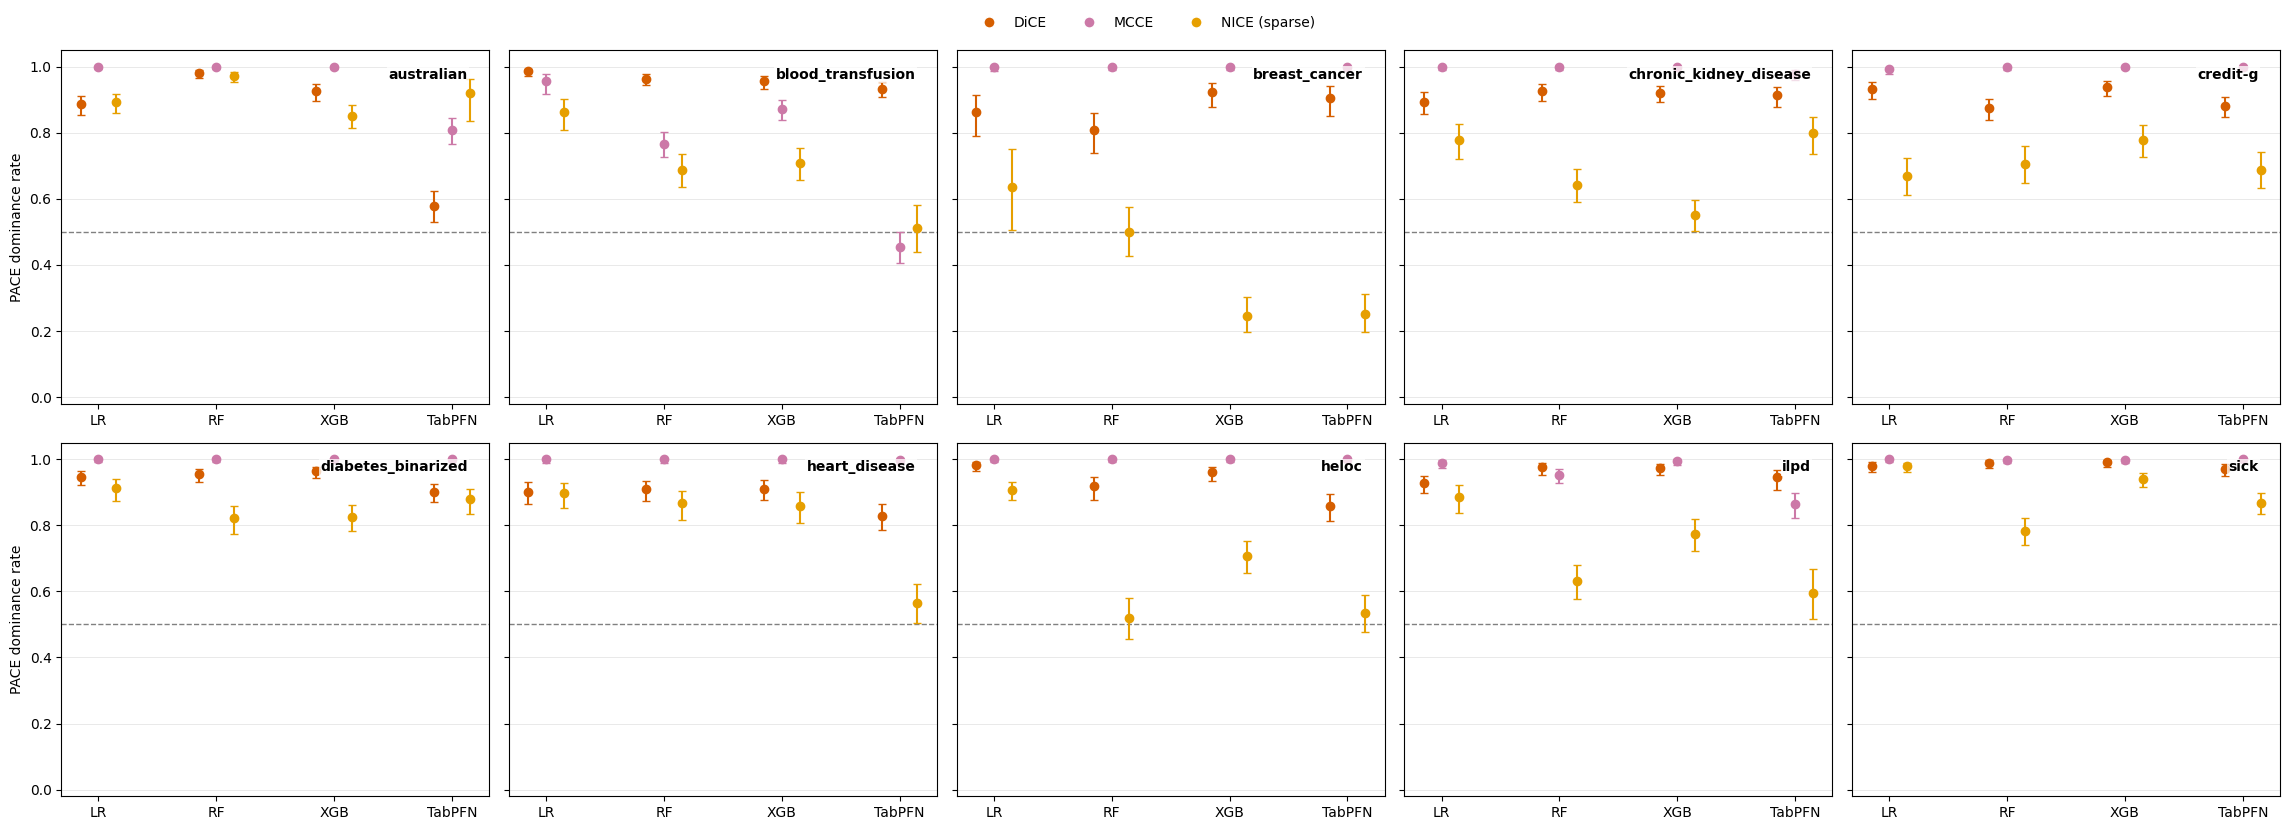

Pooled dominance rate per baseline (real, all 10 datasets):
  DiCE: 0.923 (13614/14756)
  MCCE: 0.966 (15751/16306)
  NICE (sparse): 0.755 (8827/11689)


In [15]:
df_real_pareto = joblib.load("output_realdata.joblib")
real_pareto_baselines = ["dice", "mcce", "nice_spars"]  # nice_base excluded, same as Section 4
real_pareto_datasets = sorted(df_real_pareto["dataset"].unique())  # all 10 real datasets

fig_rp, _, dom_real = plot_pareto_dominance_representative(
    df_real_pareto, baselines=real_pareto_baselines, datasets=real_pareto_datasets, ncols=5,
    outpath="real_pareto_small_multiples_all.pdf")
plt.show()

print("Pooled dominance rate per baseline (real, all 10 datasets):")
for b in real_pareto_baselines:
    d = dominance_by_group(df_real_pareto, method_a="pace", method_b=b, group=("dataset", "model"))
    n_dec = (d.n_A_dom + d.n_B_dom).sum()
    rate = d.n_A_dom.sum() / n_dec
    print(f"  {METHOD_LABELS[b]}: {rate:.3f} ({d.n_A_dom.sum()}/{n_dec})")


### Validation against `tab_pareto_real.tex`

Same trust convention as Section 5: only `tab_pareto_real.tex` (2026-09-12) is
treated as ground truth here, not `real_pareto_dom.tex` (2026-09-10,
predates later data merges).

In [16]:
PARETO_SPOT_CHECKS = [
    # (baseline, dataset, model, n_paired, n_dec, pace_wins, baseline_wins)
    ("dice", "australian", "LR", 500, 456, 404, 52),
    ("nice_spars", "breast_cancer", "TabPFN", 353, 215, 54, 161),
    ("mcce", "heloc", "RF", 436, 413, 413, 0),
    ("nice_spars", "heloc", "RF", 430, 247, 128, 119),
    ("nice_spars", "diabetes_binarized", "XGB", 500, 354, 292, 62),
]

dom_real_by_model = {b: dominance_by_group(df_real_pareto, method_a="pace", method_b=b,
                                            group=("dataset", "model")) for b in real_pareto_baselines}

all_pass = True
for baseline, dataset, model, exp_np, exp_nd, exp_pace, exp_base in PARETO_SPOT_CHECKS:
    r = dom_real_by_model[baseline]
    row = r[(r.dataset == dataset) & (r.model == model)]
    if row.empty:
        print(f"MISSING {baseline}/{dataset}/{model}")
        all_pass = False
        continue
    row = row.iloc[0]
    ok = (row.n_paired == exp_np and (row.n_A_dom + row.n_B_dom) == exp_nd
          and row.n_A_dom == exp_pace and row.n_B_dom == exp_base)
    all_pass &= ok
    status = "PASS" if ok else "CHECK"
    print(f"{status}  {baseline}/{dataset}/{model}: n_paired={row.n_paired} (exp {exp_np}), "
          f"n_dec={row.n_A_dom+row.n_B_dom} (exp {exp_nd}), pace={row.n_A_dom} (exp {exp_pace}), "
          f"baseline={row.n_B_dom} (exp {exp_base})")

print()
print("Pooled rates vs. pace.tex prose (92.3% DiCE / 96.6% MCCE / 75.5% NICE(sparse) -- "
      "corrected from a stale 75.8% found not to match tab_pareto_real.tex\'s own row sum):")


PASS  dice/australian/LR: n_paired=500 (exp 500), n_dec=456 (exp 456), pace=404 (exp 404), baseline=52 (exp 52)
PASS  nice_spars/breast_cancer/TabPFN: n_paired=353 (exp 353), n_dec=215 (exp 215), pace=54 (exp 54), baseline=161 (exp 161)
PASS  mcce/heloc/RF: n_paired=436 (exp 436), n_dec=413 (exp 413), pace=413 (exp 413), baseline=0 (exp 0)
PASS  nice_spars/heloc/RF: n_paired=430 (exp 430), n_dec=247 (exp 247), pace=128 (exp 128), baseline=119 (exp 119)
PASS  nice_spars/diabetes_binarized/XGB: n_paired=500 (exp 500), n_dec=354 (exp 354), pace=292 (exp 292), baseline=62 (exp 62)

Pooled rates vs. pace.tex prose (92.3% DiCE / 96.6% MCCE / 75.5% NICE(sparse) -- corrected from a stale 75.8% found not to match tab_pareto_real.tex's own row sum):


### Synthetic (mock) data

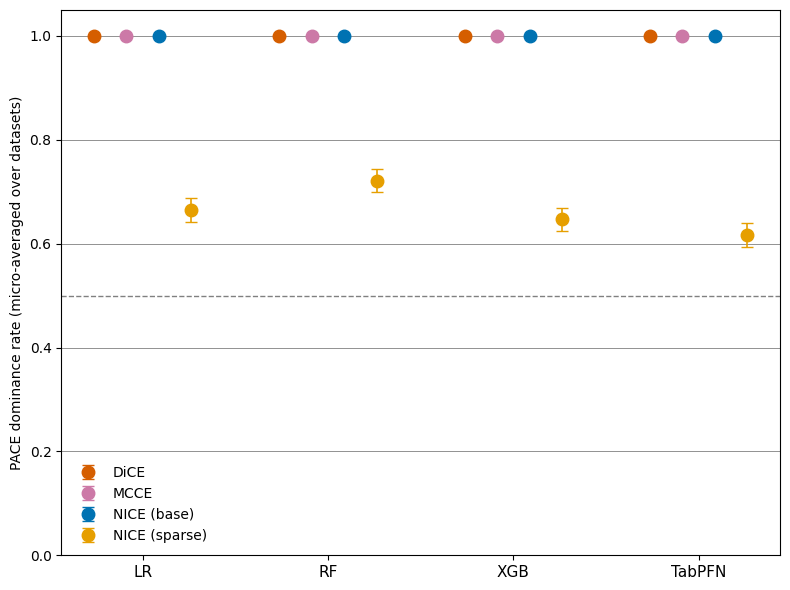

Pooled dominance rate per baseline (mock, fully pooled over model+dataset):
  DiCE: 1.0000 (8423/8423)
  MCCE: 1.0000 (9046/9046)
  NICE (base): 1.0000 (8545/8545)
  NICE (sparse): 0.6612 (4456/6739)

pace.tex claims: 100% / 100% / 100% for nice_base/dice/mcce, 66.1% (4456/6739) for nice_spars


In [17]:
df_mock_pareto = joblib.load("output_mockdata.joblib")
mock_pareto_baselines = ["dice", "mcce", "nice_base", "nice_spars"]  # all 4 included on synthetic data

dom_mock_by_model = {b: dominance_by_group(df_mock_pareto, method_a="pace", method_b=b,
                                            group=("dataset", "model")) for b in mock_pareto_baselines}

fig_mp, _, agg_mock = plot_pareto_dominance_avg(dom_mock_by_model, outpath="mock_pareto.pdf")
plt.show()

print("Pooled dominance rate per baseline (mock, fully pooled over model+dataset):")
for b in mock_pareto_baselines:
    d = dom_mock_by_model[b]
    n_dec = (d.n_A_dom + d.n_B_dom).sum()
    rate = d.n_A_dom.sum() / n_dec
    print(f"  {METHOD_LABELS[b]}: {rate:.4f} ({d.n_A_dom.sum()}/{n_dec})")
print()
print("pace.tex claims: 100% / 100% / 100% for nice_base/dice/mcce, "
      "66.1% (4456/6739) for nice_spars")


## 11. Pooled mean Δℓ2 vs ℓ0 (Figs. `real_hier_l0_vs_l2diff_by_model.pdf` /
`mock_hier_l0_vs_l2diff_by_model.pdf`)

Reproduces `pace.tex`'s F3-redesigned forest plot exactly: 2x2 grid, one
panel per classifier (name as in-panel text), ℓ0 on the x-axis, pooled mean
Δℓ2 = ℓ2(PACE) − ℓ2(baseline) from Section 4's hierarchical test on the
y-axis (negative favours PACE), 95% cluster-bootstrap CI as error bars. Dot
area is proportional to $k_{\mathrm{datasets}}$ (contributing clusters);
cells with $k<3$ are drawn hollow/grey, since a mean over fewer than 3
clusters carries little information about between-dataset variation. Reuses
`hier_results` from Section 4 directly for the real panel (already computed
and validated there) rather than recomputing.

In [18]:
def plot_l0_vs_l2diff_by_model(hier_df, *, baselines, models=("LR", "RF", "XGB", "TabPFN"), ncols=2,
                                figsize_per_panel=(4.6, 4.0), size_min=25, size_scale=18, k_hollow=3,
                                outpath=None):
    nrows = int(np.ceil(len(models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_panel[0]*ncols, figsize_per_panel[1]*nrows))
    axes_flat = np.atleast_1d(axes).flatten()

    for idx, model in enumerate(models):
        ax = axes_flat[idx]
        row, col = idx // ncols, idx % ncols
        ax.axhline(0.0, linestyle="--", linewidth=1, color="grey")
        for b in baselines:
            sub = hier_df[(hier_df.baseline == b) & (hier_df.model == model)].sort_values("l0")
            for _, r in sub.iterrows():
                k = int(r["k"])
                size = size_min + size_scale * k
                hollow = k < k_hollow
                if not pd.isna(r["ci_lo"]):
                    err_lo = max(0.0, r["mean_delta_l2"] - r["ci_lo"])
                    err_hi = max(0.0, r["ci_hi"] - r["mean_delta_l2"])
                    ax.errorbar(r["l0"], r["mean_delta_l2"], yerr=[[err_lo], [err_hi]],
                               fmt="none", ecolor=COLORS[b], capsize=2, zorder=1)
                if hollow:
                    ax.scatter(r["l0"], r["mean_delta_l2"], s=size, facecolors="none",
                              edgecolors="grey", linewidths=1.2, zorder=2)
                else:
                    ax.scatter(r["l0"], r["mean_delta_l2"], s=size, facecolors=COLORS[b],
                              edgecolors="none", alpha=0.85, zorder=2)
        ax.text(0.95, 0.95, model, transform=ax.transAxes, fontsize=11, fontweight="bold",
               ha="right", va="top", bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1))
        if row == nrows - 1:
            ax.set_xlabel(r"$\ell_0$")
        if col == 0:
            ax.set_ylabel(r"Mean $\Delta\ell_2$ (PACE $-$ baseline)")
        ax.grid(True, linewidth=0.4, alpha=0.5)

    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS[b], markersize=8,
                          label=METHOD_LABELS[b]) for b in baselines]
    handles.append(plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="none",
                              markeredgecolor="grey", markersize=8, label=f"k<{k_hollow} datasets"))
    fig.legend(handles=handles, loc="upper center", ncol=len(baselines)+1, bbox_to_anchor=(0.5, 1.05),
              frameon=False)
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, format="pdf", dpi=300, bbox_inches="tight")
    return fig, axes_flat


### Real data (reuses `hier_results` from Section 4)

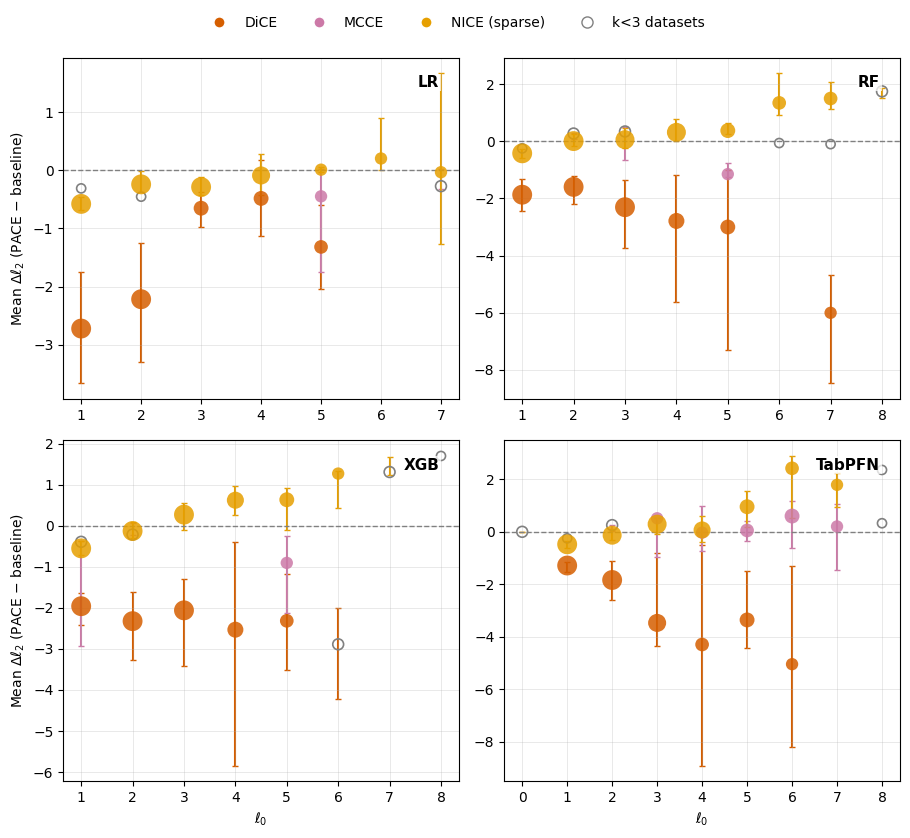

In [19]:
fig_hr, _ = plot_l0_vs_l2diff_by_model(hier_results, baselines=["dice", "mcce", "nice_spars"],
                                       outpath="real_hier_l0_vs_l2diff_by_model.pdf")
plt.show()


### Synthetic (mock) data

Mock hierarchical cells by baseline: {'nice_spars': 29}


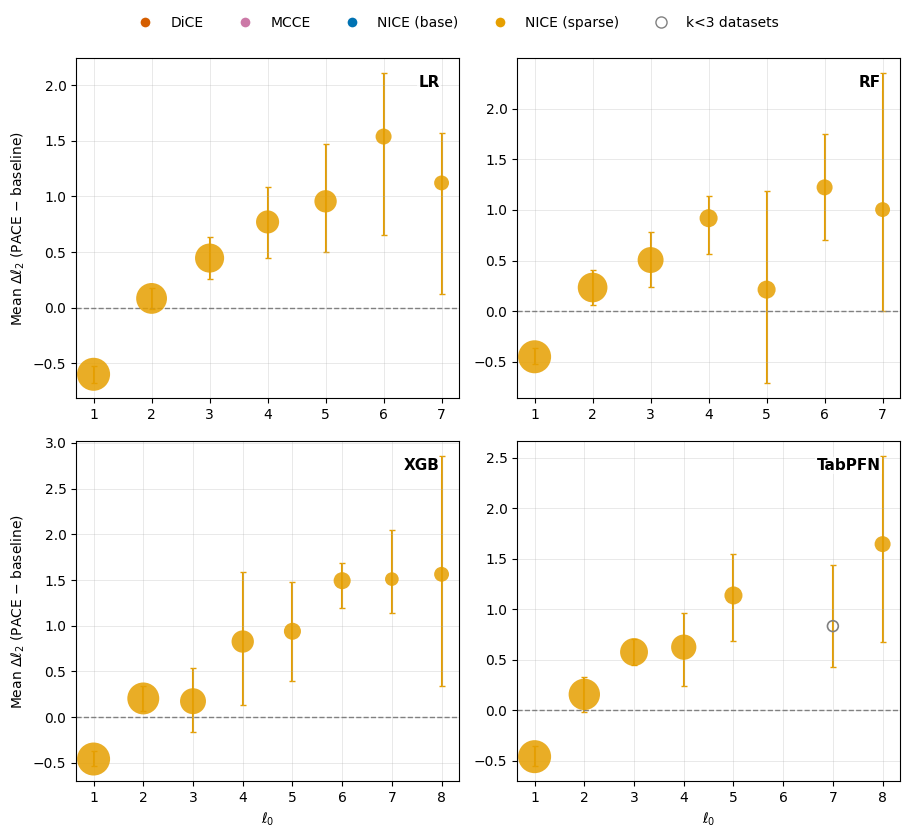

In [20]:
df_mock_hier = joblib.load("output_mockdata.joblib")
wide_mock_hier, _, _ = make_paired_table(df_mock_hier)

hier_results_mock = combine_hierarchical_results(wide_mock_hier, baselines=["dice", "mcce", "nice_base", "nice_spars"],
                                                  models=["LR", "RF", "XGB", "TabPFN"])

print(f"Mock hierarchical cells by baseline: {hier_results_mock.groupby('baseline').size().to_dict()}")

fig_hm, _ = plot_l0_vs_l2diff_by_model(hier_results_mock, baselines=["dice", "mcce", "nice_base", "nice_spars"],
                                       outpath="mock_hier_l0_vs_l2diff_by_model.pdf")
plt.show()
